In [1]:
import sys, pdb, string,os, glob
sys.path.append('../gizmo_analysis/pysrc/')
#import my_utils as u, 
import numpy as np
from numpy import log10 as log, log as ln
import h5py
from scipy import interpolate
import astropy, astropy.cosmology
from astropy import units as un, constants as cons
from astropy.cosmology import Planck15 as cosmo
import pylab as pl, matplotlib
from matplotlib import cm
homedir = os.environ["HOME"]
#projectdir = homedir+'/Dropbox/github_repositories/cgm_models/TurbDominated/'
#import my_utils as u

In [2]:
Mhalo=1e12*un.Msun
fgas=0.5
M_1 = Mhalo * 0.158 * fgas
l_1 = 20*un.kpc * 200*un.km/un.s
AMD = lambda l: M_1 / l_1 * np.e**(-l/l_1)

13337.986189903717
20137.40284203782
33261.05927011294


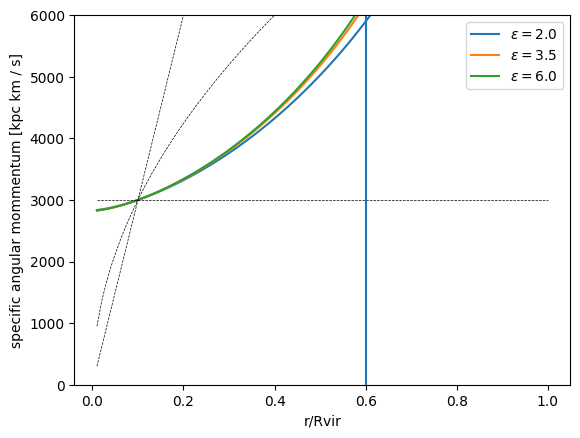

In [7]:
import numpy as np
import pylab as pl

f_removed = 0.4 #CGM mass fraction relative to halo baryon budget. The remaining (1-f_gas) fraction of the AMD is removed 
a = -1.5 #density slope
j_at_01Rvir = 3000. # reference value

def j(r2Rvir,j_vir,eps):
    ln_arg = 1-f_removed*(1-np.e**-eps) - (1-f_removed)*r2Rvir**(a+3)*(1-np.e**-eps)
    return -j_vir/eps * np.log(ln_arg)


#plot j profile
r2Rvirs = np.arange(0.01,1.005,0.01)
for epsilon in (2,3.5,6): #shape parameter found from sims to be in the range 2-6. Exact value has small affect at r<0.8Rvir
    #find j_vir so we get j(0.1Rvir)=3000*kpc*km/s
    jvir = j_at_01Rvir/j(0.1,1.,epsilon)
    pl.plot(r2Rvirs,j(r2Rvirs,jvir,epsilon),label=r'$\epsilon=%.1f$'%epsilon)
    print(jvir)
# comparison to power laws:
[pl.plot(r2Rvirs,j_at_01Rvir*(r2Rvirs/0.1)**i,c='k',ls='--',lw=0.5) for i in (0,0.5,1.)]
pl.axvline(150/250.)
pl.ylim(0,6000)
pl.legend()
pl.xlabel(r'r/Rvir')
pl.ylabel(r'specific angular mommentum [kpc km / s]')
pl.savefig('jProfilePezzulli17.png',bbox_inches='tight',dpi=600)